# Embedding distances

### Import/load stuff

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

MISSING_LABEL = "Non-typeable"
NONCBL_LABEL = "NON-CBL"
MIN_COUNT = 2 

EMBEDDINGS_PATH = "/Users/tajmira1/Desktop/contrastive_embeddings.npz"
LABELS_PATH = "/Users/tajmira1/Desktop/GPS_All_clean_labels.tsv"
NONCBL_PATH = None  # "/nfs/research/jlees/tajmirri/gps_analysis/new_data/noncbl_base_embeddings.npy" # 2k subsample 
OUT_PATH = "plot.pdf"

DIST_FUNCTION = "cos"  # "l2" or "cos"
distance_function = cosine_distances if DIST_FUNCTION == "cos" else euclidean_distances


### Helper functions

In [3]:
SEROTYPE_GROUPS = {
    "6A": "6",
    "6B": "6",
    "6C": "6",
    "6D": "6",
    "6E(6B)": "6",
    "7B": "7B_7C_40",
    "7C": "7B_7C_40",
    "7F": "7A_7F",
    "9A": "9",
    "9L": "9",
    "9N": "9",
    "9V": "9",
    "10A": "10",
    "10B": "10",
    "10C": "10",
    "10F": "10",
    "10X": "33G",
    "11A": "11",
    "11B": "11",
    "11C": "11",
    "11E": "11",
    "12A": "12_44_46",
    "12B": "12_44_46",
    "12F": "12_44_46",
    "15A": "15",
    "15B": "15",
    "15C": "15",
    "15B/15C": "15",
    "15F": "15",
    "18A": "18",
    "18B": "18",
    "18C": "18",
    "18F": "18",
    "19A": "19A",
    "19B": "19B_19C",
    "19F": "19F",
    "20": "20",
    "20A": "20",
    "20B": "20",
    "22A": "22",
    "22F": "22",
    "23A": "23",
    "23B": "23",
    "23B1": "23",
    "23F": "23",
    "24": "24",
    "24A": "24",
    "24F": "24",
    "25A": "25A_25F_38",
    "25F": "25A_25F_38",
    "28A": "28",
    "28F": "28",
    "33A": "33A_33F_37",
    "33A/33F": "33A_33F_37",
    "33B": "33B_33D",
    "33D": "33B_33D",
    "33F": "33A_33F_37",
    "35A": "35A_35C_42",
    "35B": "35B_35D",
    "35B/35D": "35B_35D",
    "35C": "35A_35C_42",
    "35D": "35B_35D",
    "37": "33A_33F_37",
    "38": "25A_25F_38",
    "39X": "10D",
    "40": "7B_7C_40",
    "42": "35A_35C_42",
    "46": "12_44_46",
    "NON-CBL": "NON-CBL",
}


def map_serotype_to_group(serotype):
    """ Map serotype to a more coarse label by
    looking it up in the serogroup/genogroups data. """
    if isinstance(serotype, str):
        if serotype in SEROTYPE_GROUPS:
            return SEROTYPE_GROUPS[serotype]
    print(f"Warning: {serotype} not found in mapping.")
    return serotype

In [7]:
def plot_everything(distances, title="Pairwise Distances", xlabel="Distance", ylabel="Density", save_path=None, **kwargs):
    print(f"Plotting {title} with {len(distances)} distances.")
    plt.figure(figsize=(8, 6))
    sns.kdeplot(distances, fill=True, color='skyblue')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(0, 2)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path)
    plt.show()

## Embeddings Cosine Similarity

In [2]:
# Load embeddings
X = np.load(EMBEDDINGS_PATH)
labels = pd.read_csv(LABELS_PATH, index_col=0, sep="\t")

# In case "someone" has messed up while cleaning the data
is_duplicate = labels.duplicated()
if is_duplicate.any():
    print("Dropping duplicate label rows...")
    labels = labels[~is_duplicate]

labels['Serotype'] = labels['Serotype'].fillna(MISSING_LABEL)
known_indices = labels['Serotype'] != MISSING_LABEL

# Drop samples with labels that only occur once
underrep_labels = labels['Serotype'].value_counts()[labels['Serotype'].value_counts() < MIN_COUNT].index
if underrep_labels.any():
    print(f"Dropping serotypes with less than {MIN_COUNT} samples:", *underrep_labels.to_list())
    known_indices &= ~labels['Serotype'].isin(underrep_labels)

labels = labels[known_indices]
is_emb_npz = isinstance(X, np.lib.npyio.NpzFile)
if is_emb_npz:
    cbl_prefix = lambda k: f"cbl|{k}"
    X = np.array([X[cbl_prefix(key)] for key in labels.index if cbl_prefix(key) in X])

# add "NON-CBL" to the labels
if NONCBL_PATH is not None and os.path.exists(NONCBL_PATH):
    print(f"Loading NON-CBL embeddings from {NONCBL_PATH}...")
    X_NONCBL = np.load(NONCBL_PATH)
    X = np.concatenate([X, X_NONCBL], axis=0)
    labels = pd.concat([labels, pd.DataFrame({"Serotype": [NONCBL_LABEL] * X_NONCBL.shape[0]})], axis=0)

labels = labels["Serotype"].reset_index(drop=True)

Dropping duplicate label rows...
Dropping serotypes with less than 2 samples: 32 35B/35D 10C 25A 33A/33F 41F 32F


## Everything against everything

### Construct

In [16]:
dist_path = "/Users/tajmira1/Desktop/cosine_distances_filtered.npz"
# EMBEDDINGS_PATH.replace("contrastive_embeddings.npy", "pairwise_distances.csv")
if not os.path.exists(dist_path):
    print("Computing pairwise distances...")
    dist_matrix = distance_function(X, X)
    pairwise_distances = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]
    print(f"Saving pairwise distances to {dist_path}...")
    np.savez(dist_path, distances=pairwise_distances, size=dist_matrix.shape[0])
else:
    print("Loading pairwise distances...")
    dist_data = np.load(dist_path)
    pairwise_distances = dist_data['distances']
    dist_matrix = np.zeros((dist_data['size'], dist_data['size']))
    dist_matrix[np.triu_indices_from(dist_matrix, k=1)] = pairwise_distances
    dist_matrix += dist_matrix.T
    np.fill_diagonal(dist_matrix, 0)

Computing pairwise distances...
Saving pairwise distances to /Users/tajmira1/Desktop/cosine_distances_filtered.npz...


In [36]:
# pairwise_distances.shape  # 34560 != 24112 you fucking idiot
noncbl = np.load(EMBEDDINGS_PATH)
noncbl_prefix = lambda k: f"non-cbl|{k}"
noncbl = np.array(list(map(lambda kk: noncbl[kk], filter(lambda k: k.startswith("non-cbl|"), noncbl.keys()))))  # [noncbl[noncbl_prefix(key)] for key in noncbl])
noncbl.shape

(24367, 128)

Plotting Pairwise Cosine Distances Density with 100000 distances.


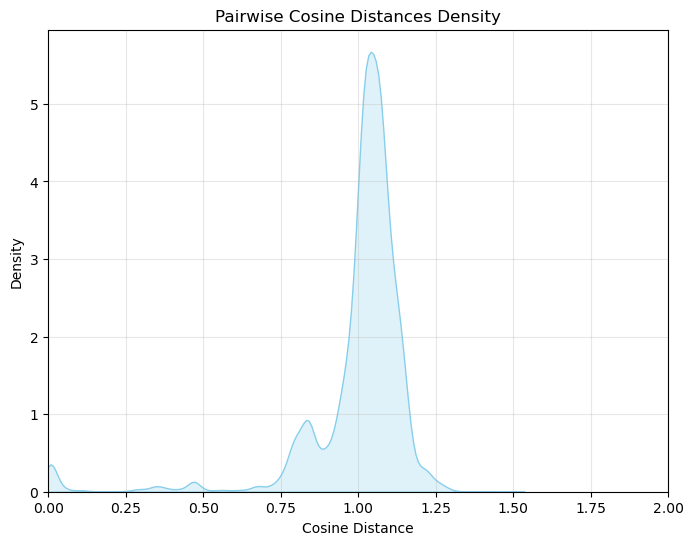

In [21]:
TOP_N = 100000
# Plot the density
plot_everything(pairwise_distances[:TOP_N], title="Pairwise Cosine Distances Density", xlabel="Cosine Distance", ylabel="Density", save_path=OUT_PATH)
    


### Try Euclidean instead of Cosine

Computing pairwise distances...
Saving pairwise distances to /Users/tajmirri/Documents/Workspace/data/gps/euc_distances.csv...
Plotting Pairwise L2 Distances Density with 290682216 distances.


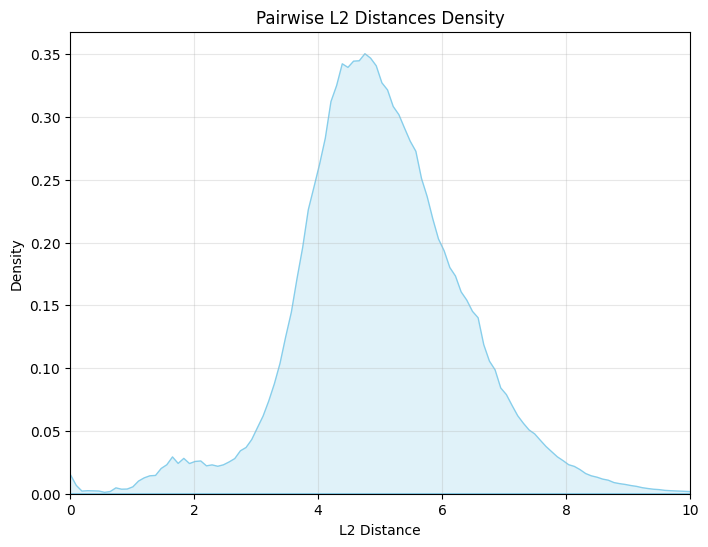

In [17]:
dist_path = EMBEDDINGS_PATH.replace("contrastive_embeddings.npy", "euc_distances.csv")
if not os.path.exists(dist_path):
    print("Computing pairwise distances...")
    dist_matrix = euclidean_distances(X, X)
    euc_distances = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]
    print(f"Saving pairwise distances to {dist_path}...")
    np.savez(dist_path, distances=euc_distances, size=dist_matrix.shape[0])
else:
    print("Loading pairwise distances...")
    dist_data = np.load(dist_path)
    euc_distances = dist_data['distances']
    dist_matrix = np.zeros((dist_data['size'], dist_data['size']))
    dist_matrix[np.triu_indices_from(dist_matrix, k=1)] = euc_distances
    dist_matrix += dist_matrix.T
    np.fill_diagonal(dist_matrix, 0)

# Plot the density
plot_everything(euc_distances, title="Pairwise L2 Distances Density", xlabel="L2 Distance", ylabel="Density")

### Fit GMM (2 components) + Cheating

Fitting GMM with 1000000 distances.
GMM means: [[1.58079067]
 [5.11843058]]
GMM covariances: [[[0.51661454]]

 [[1.42142029]]]
GMM weights: [0.03086387 0.96913613]

Plotting GMM fit with 1000000 distances.


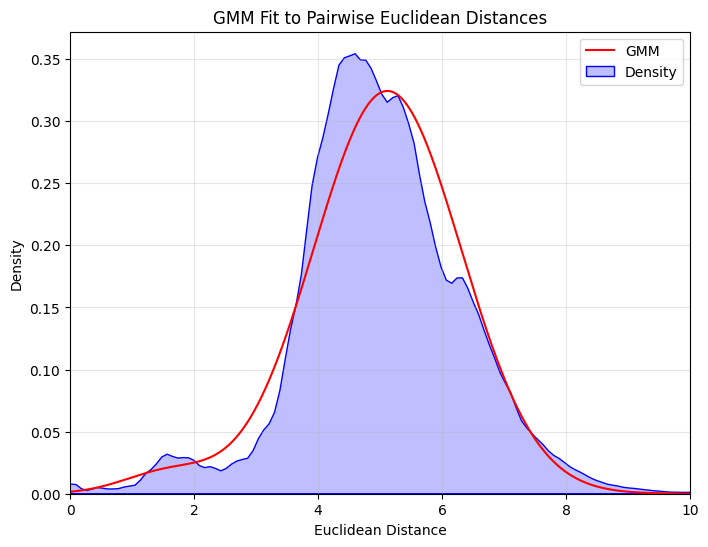

In [22]:
TOP = 1000_000
def plot_gmm(distances, means_init, weights_init, title="GMM Fit", xlabel="Distance", ylabel="Density", save_path=None):
    print(f"Fitting GMM with {len(distances)} distances.")
    gmm = GaussianMixture(n_components=2, covariance_type='full', means_init=means_init, weights_init=weights_init, precisions_init=None, random_state=0, n_init=30) 
    gmm.fit(distances[:TOP].reshape(-1, 1))
    print("GMM means:", gmm.means_)
    print("GMM covariances:", gmm.covariances_)
    print("GMM weights:", gmm.weights_)
    print(f"\nPlotting GMM fit with {len(distances)} distances.")
    x = np.linspace(0, 10, 1000)
    y = np.exp(gmm.score_samples(x.reshape(-1, 1)))
    
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, label='GMM', color='red')
    sns.kdeplot(distances, fill=True, color='blue', label='Density')
    # plt.hist(pairwise_distances[:TOP], bins=50, density=True, alpha=0.5, label='Histogram', color='blue')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(0, 10)
    plt.grid(alpha=0.3)
    plt.legend()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()


plot_gmm(euc_distances[:TOP], means_init=np.array([[1.9], [4.5]]),# Cosine: np.array([[0.08], [0.75]]),
    weights_init=np.array([0.1, 0.9]),
    title="GMM Fit to Pairwise Euclidean Distances",
    xlabel="Euclidean Distance", ylabel="Density"
)


In [78]:
norm.ppf(0.98, loc=gmm.means_[-1], scale=np.sqrt(gmm.covariances_[-1][0]))

array([1.25989056])

BGM means: [[0.7358749 ]
 [0.78494276]]
BGM covariances: [[[0.09540719]]

 [[0.03868307]]]
BGM weights: [0.43094563 0.56905437]


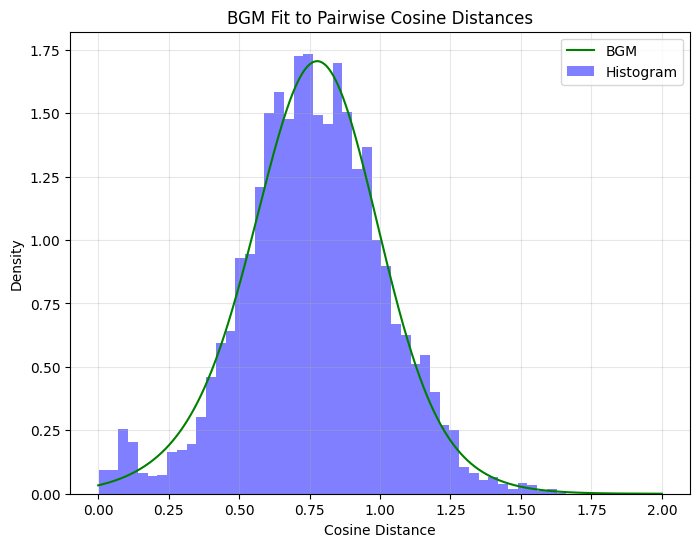

In [73]:
from sklearn.mixture import BayesianGaussianMixture
TOP = 100000
bgm = BayesianGaussianMixture(
    n_components=2,
    weight_concentration_prior_type='dirichlet_distribution',
    weight_concentration_prior=0.01,   # small → encourages uneven weights
    covariance_type='full',
    max_iter=1000,
    random_state=42
)
bgm.fit(pairwise_distances[:TOP].reshape(-1,1))
print("BGM means:", bgm.means_)
print("BGM covariances:", bgm.covariances_)
print("BGM weights:", bgm.weights_)
# Plot the BGM
x = np.linspace(0, 2, 1000)
y = np.exp(bgm.score_samples(x.reshape(-1, 1)))
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='BGM', color='green')
plt.hist(pairwise_distances[:TOP], bins=50, density=True, alpha=0.5, label='Histogram', color='blue')
plt.title('BGM Fit to Pairwise Cosine Distances')
plt.xlabel('Cosine Distance')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Fit 1 normal

Normal parameters: (np.float32(0.7637971), np.float32(0.25242344))


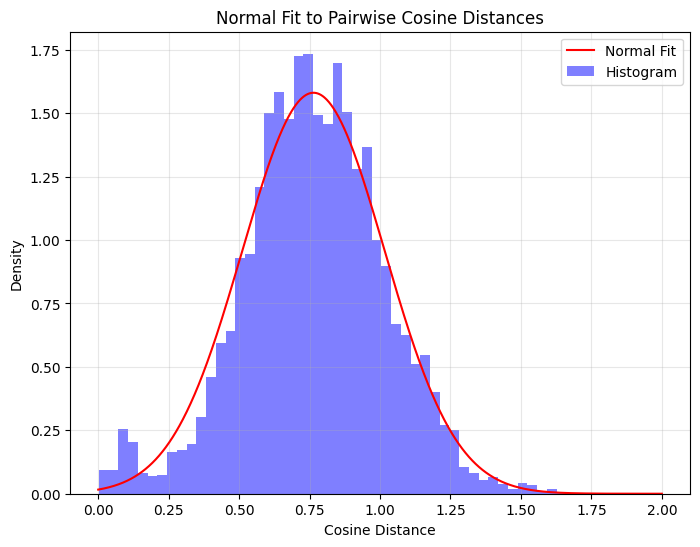

In [ ]:
def plot_normal_fit(distances, title="Normal Fit", xlabel="Distance", ylabel="Density", save_path=None, max_x=10):
    normal_parameters = norm.fit(pairwise_distances[:TOP])
    print("Normal parameters:", normal_parameters)
    print(f"Plotting normal fit with {len(distances)} distances.")
    x = np.linspace(0, max_x, 1000)
    y = norm.pdf(x, *normal_parameters)
    
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, label='Normal Fit', color='red')
    sns.kdeplot(distances, fill=True, color='blue', label='Density')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(0, max_x)
    plt.grid(alpha=0.3)
    plt.legend()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

plot_normal_fit(pairwise_distances[:TOP], title="Normal Fit to Pairwise Cosine Distances",
    xlabel="Cosine Distance", max_x=2
)

In [68]:
norm.ppf(0.98, *normal_parameters)

np.float64(1.2822114599312318)

## Individual Serogroups

#### Mapping to sero(/geno)groups

In [10]:
group_labels = labels.map(map_serotype_to_group)
print("Serotype groups count + 1 (Non-CBL):", len(group_labels.unique()))

Serotype groups count + 1 (Non-CBL): 46


### Sero(/geno)groups + underlying distribution components (sorted by data abundance)

7it [00:15,  1.52s/it]/var/folders/7_/8s9_lwfx6vg56_n8k00qcpmc0000gp/T/ipykernel_44735/3854962972.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=axes[i], alpha=0.5, label=sub_serotype, linestyle='dashed')  # , color='orange'
27it [00:20,  9.71it/s]/var/folders/7_/8s9_lwfx6vg56_n8k00qcpmc0000gp/T/ipykernel_44735/3854962972.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=axes[i], alpha=0.5, label=sub_serotype, linestyle='dashed')  # , color='orange'
29it [00:20, 11.37it/s]/var/folders/7_/8s9_lwfx6vg56_n8k00qcpmc0000gp/T/ipykernel_44735/3854962972.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pairwise_distances_subserotype, fill=Fa

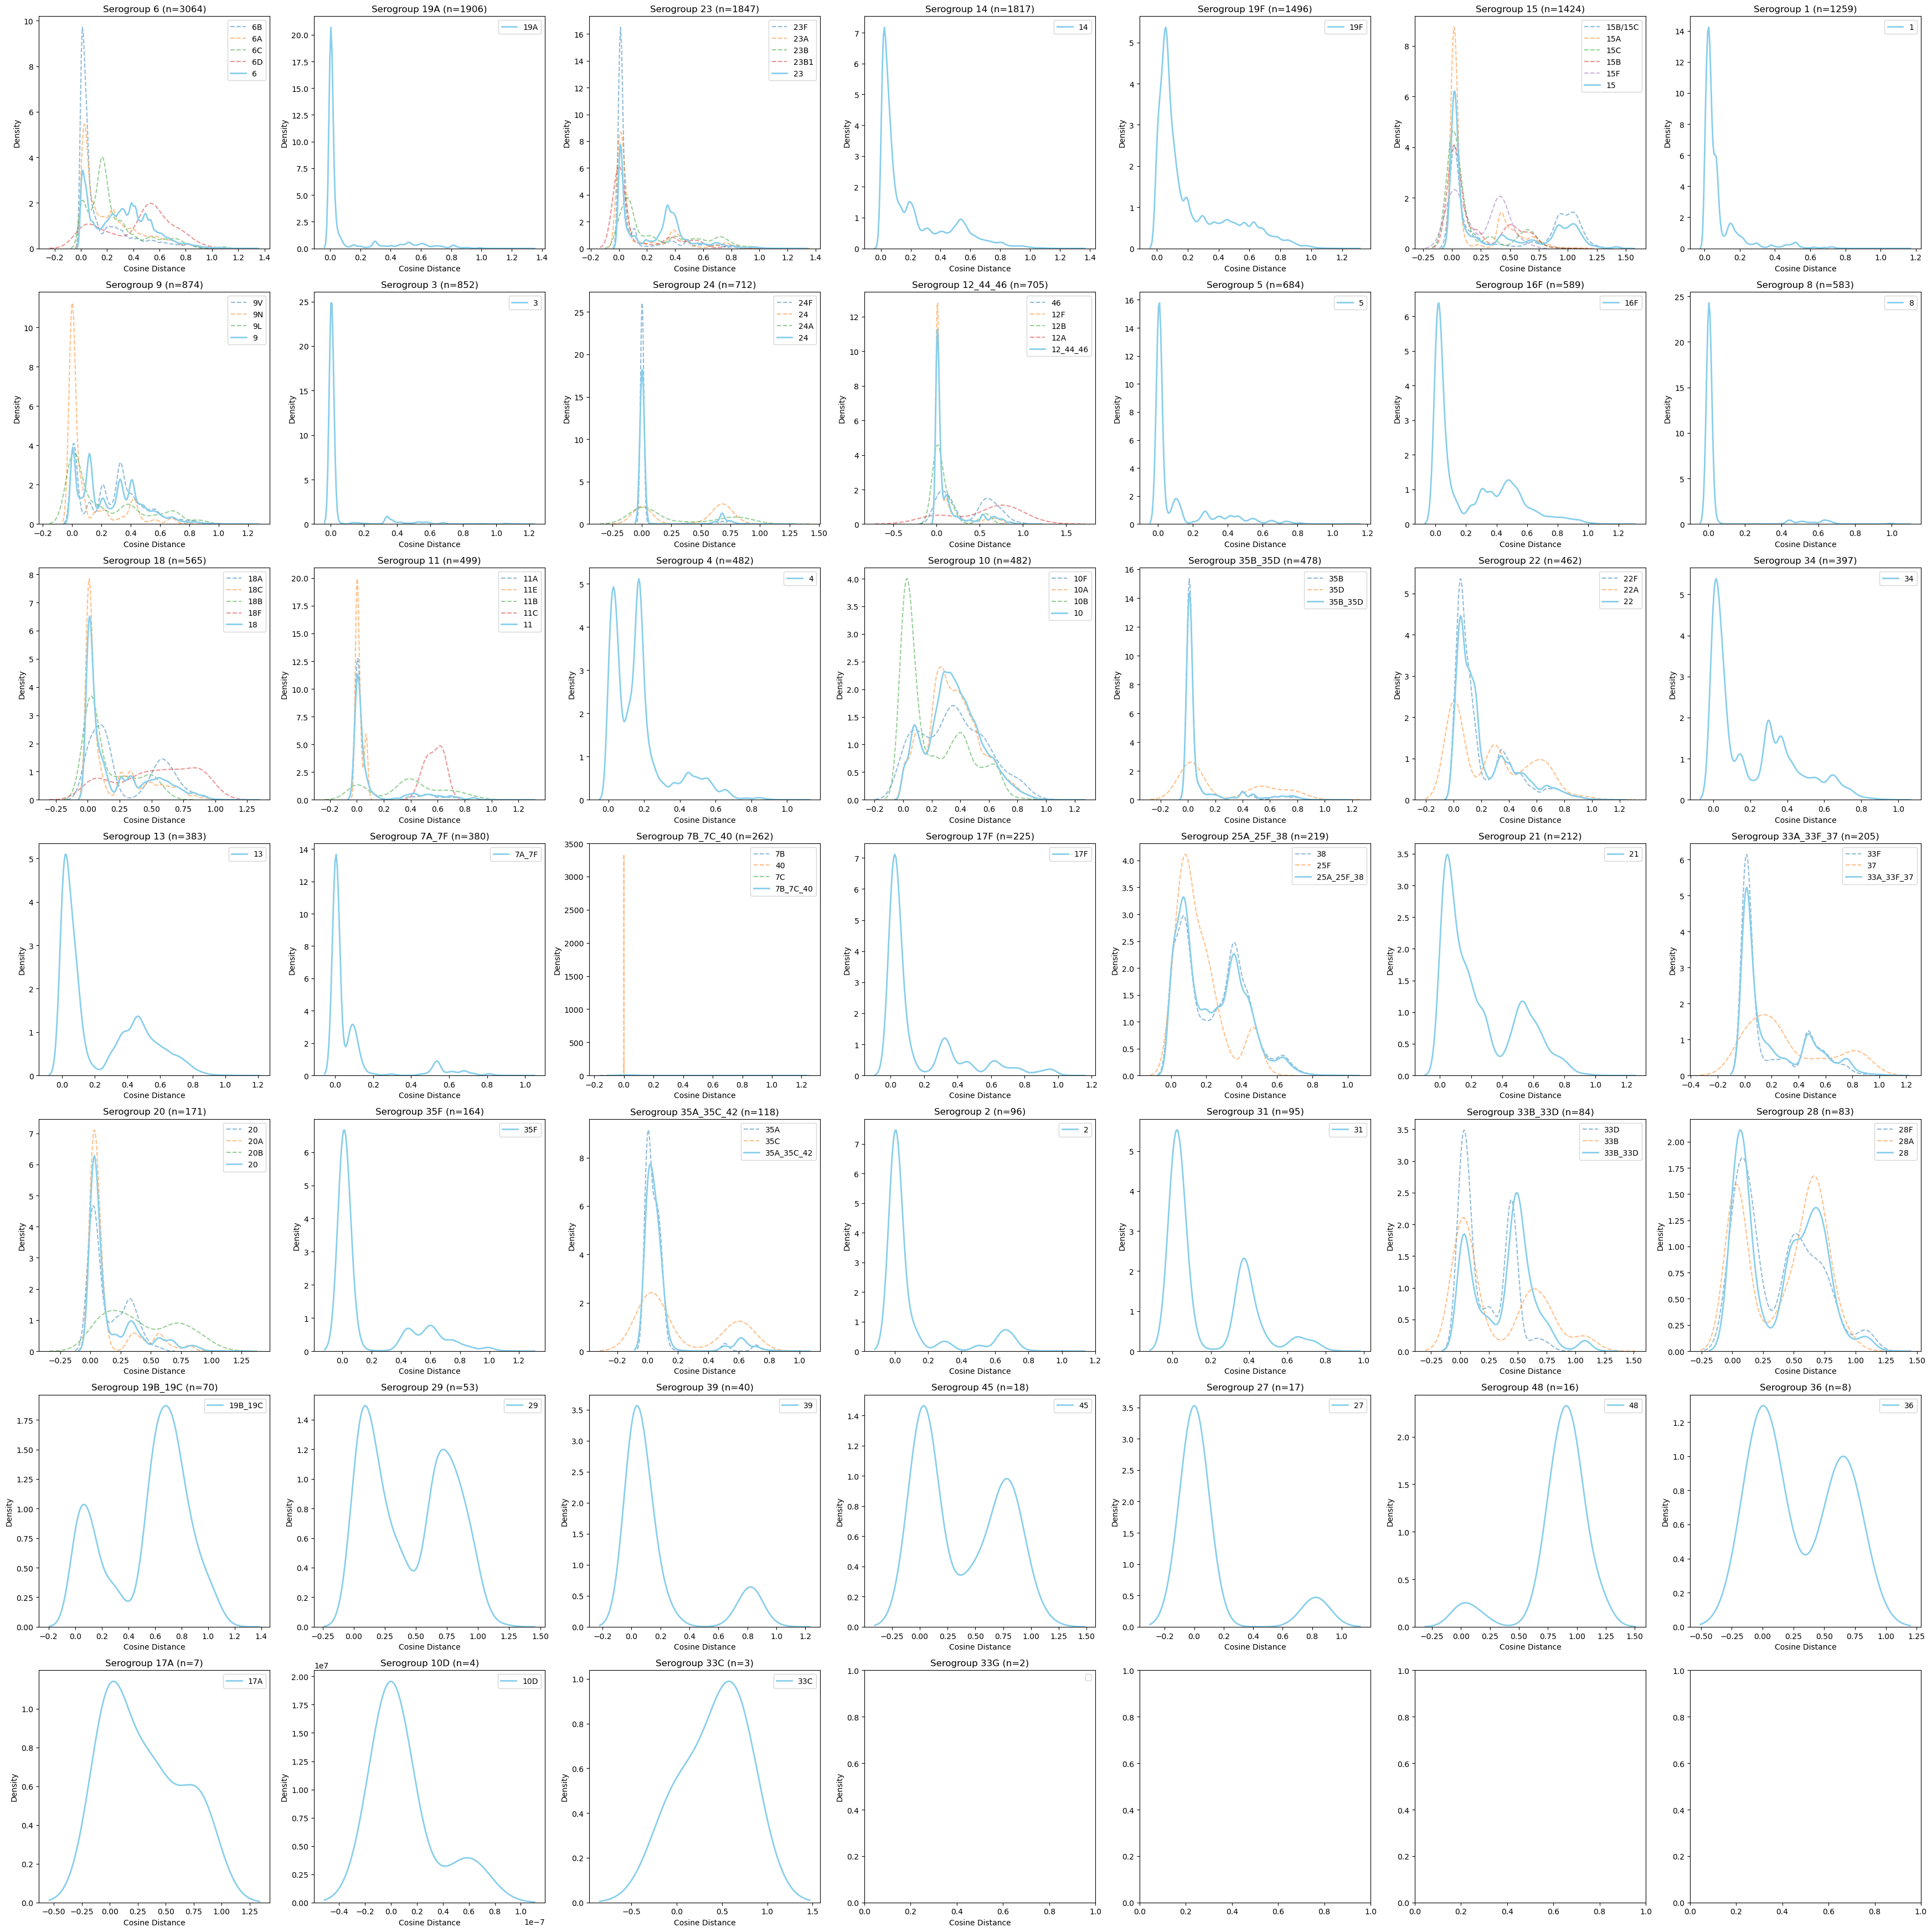

In [22]:
# SHOW_TOP = 25
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(7, 7, figsize=(35, 35))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    # if i >= 25:  # Limit to the top 25 serotypes
    #     break

    # Filter X based on the current serotype
    # print(f"Processing serotype: {serotype} (n={count})")
    serotype_indices = group_labels[group_labels == serogroup].index
    submatrix = dist_matrix[serotype_indices][:, serotype_indices]
    pairwise_distances_serotype = submatrix[np.triu_indices_from(submatrix, k=1)]

    # plot the fine labels on top of the coarse labels
    sub_serotypes = labels[serotype_indices].unique()
    if len(sub_serotypes) > 1:
        # Create a new axis for the sub-serotypes
        for sub_serotype in sub_serotypes:
            sub_serotype_indices = labels[labels == sub_serotype].index
            submatrix = dist_matrix[sub_serotype_indices][:, sub_serotype_indices]
            pairwise_distances_subserotype = submatrix[np.triu_indices_from(submatrix, k=1)]
            sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=axes[i], alpha=0.5, label=sub_serotype, linestyle='dashed')  # , color='orange'
            # axes[i].legend(title="Sub-serotype", loc='upper right')

    # Plot the density
    ax = axes[i]
    sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=2)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')

# Adjust layout
plt.tight_layout()
plt.show()

# Beta distribution

In [27]:
from scipy.stats import beta

def fit_distributions(labels: pd.DataFrame, distances: np.ndarray, min_serogroup_size: int):
    """
    Fit normal and beta distributions for serogroups based on pairwise distances.
    """
    labels_cp = labels.reset_index().iloc[:, 1]  # Ensure labels are indexed from 0
    serogroups = labels_cp.unique()
    beta_params = {}
    for serogroup in serogroups:
        indices = labels_cp[labels_cp == serogroup].index
        if len(indices) < min_serogroup_size:
            print(f"Skipping serogroup {serogroup} with size {len(indices)} < {min_serogroup_size}.")
            continue
        sub_distances = distances[np.ix_(indices, indices)][np.triu_indices(len(indices), k=1)]
        sub_distances = sub_distances[sub_distances > 1e-6]
        a, b, loc, scale = beta.fit(sub_distances, floc=0, fscale=2)
        beta_params[serogroup] = {"a": a, "b": b}  # Should I store "loc": loc, "scale": scale?
        
    # Could either fit a normal or a GMM with 2 components
    normal_params = norm.fit(distances.flatten())
    normal_params = {
        "mu": normal_params[0],
        "sigma": normal_params[1]
    }
    return beta_params, normal_params

fit_distributions(labels, dist_matrix, 10)

Skipping serogroup 33C with size 3 < 10.
Skipping serogroup 11E with size 9 < 10.
Skipping serogroup 36 with size 8 < 10.
Skipping serogroup 17A with size 7 < 10.
Skipping serogroup 39X with size 4 < 10.
Skipping serogroup 10X with size 2 < 10.
Skipping serogroup 11C with size 4 < 10.
Skipping serogroup 9A with size 2 < 10.
Skipping serogroup 12A with size 5 < 10.
Skipping serogroup 42 with size 2 < 10.
Skipping serogroup 33A with size 2 < 10.


({'23F': {'a': 0.4069381464566588, 'b': 6.325628275738145},
  '5': {'a': 0.3678139609129201, 'b': 5.322435473090904},
  '3': {'a': 0.30618955899780537, 'b': 8.188496991200111},
  '20': {'a': 0.6491754087721353, 'b': 7.787648636032766},
  '19F': {'a': 0.796353548429621, 'b': 5.874654338858341},
  '1': {'a': 0.7610140756243935, 'b': 17.085900840998747},
  '22F': {'a': 0.9445205025536489, 'b': 8.053384832942244},
  '19A': {'a': 0.2968513380457013, 'b': 4.672748909591431},
  '15B/15C': {'a': 0.4516026371074131, 'b': 1.5831245833546417},
  '13': {'a': 0.5531972511409098, 'b': 4.195756864696975},
  '6B': {'a': 0.50837454038371, 'b': 5.923556290682975},
  '9V': {'a': 0.8113254092153869, 'b': 5.009234665624322},
  '11A': {'a': 0.3224291299437895, 'b': 5.52331899318613},
  '8': {'a': 0.27116456443083464, 'b': 8.664966304310747},
  '23A': {'a': 0.32153807507376514, 'b': 3.750998592502548},
  '16F': {'a': 0.5815602682748668, 'b': 4.201947654084915},
  '17F': {'a': 0.4953765649550757, 'b': 5.34803

## One vs. All

46it [11:44, 15.31s/it]


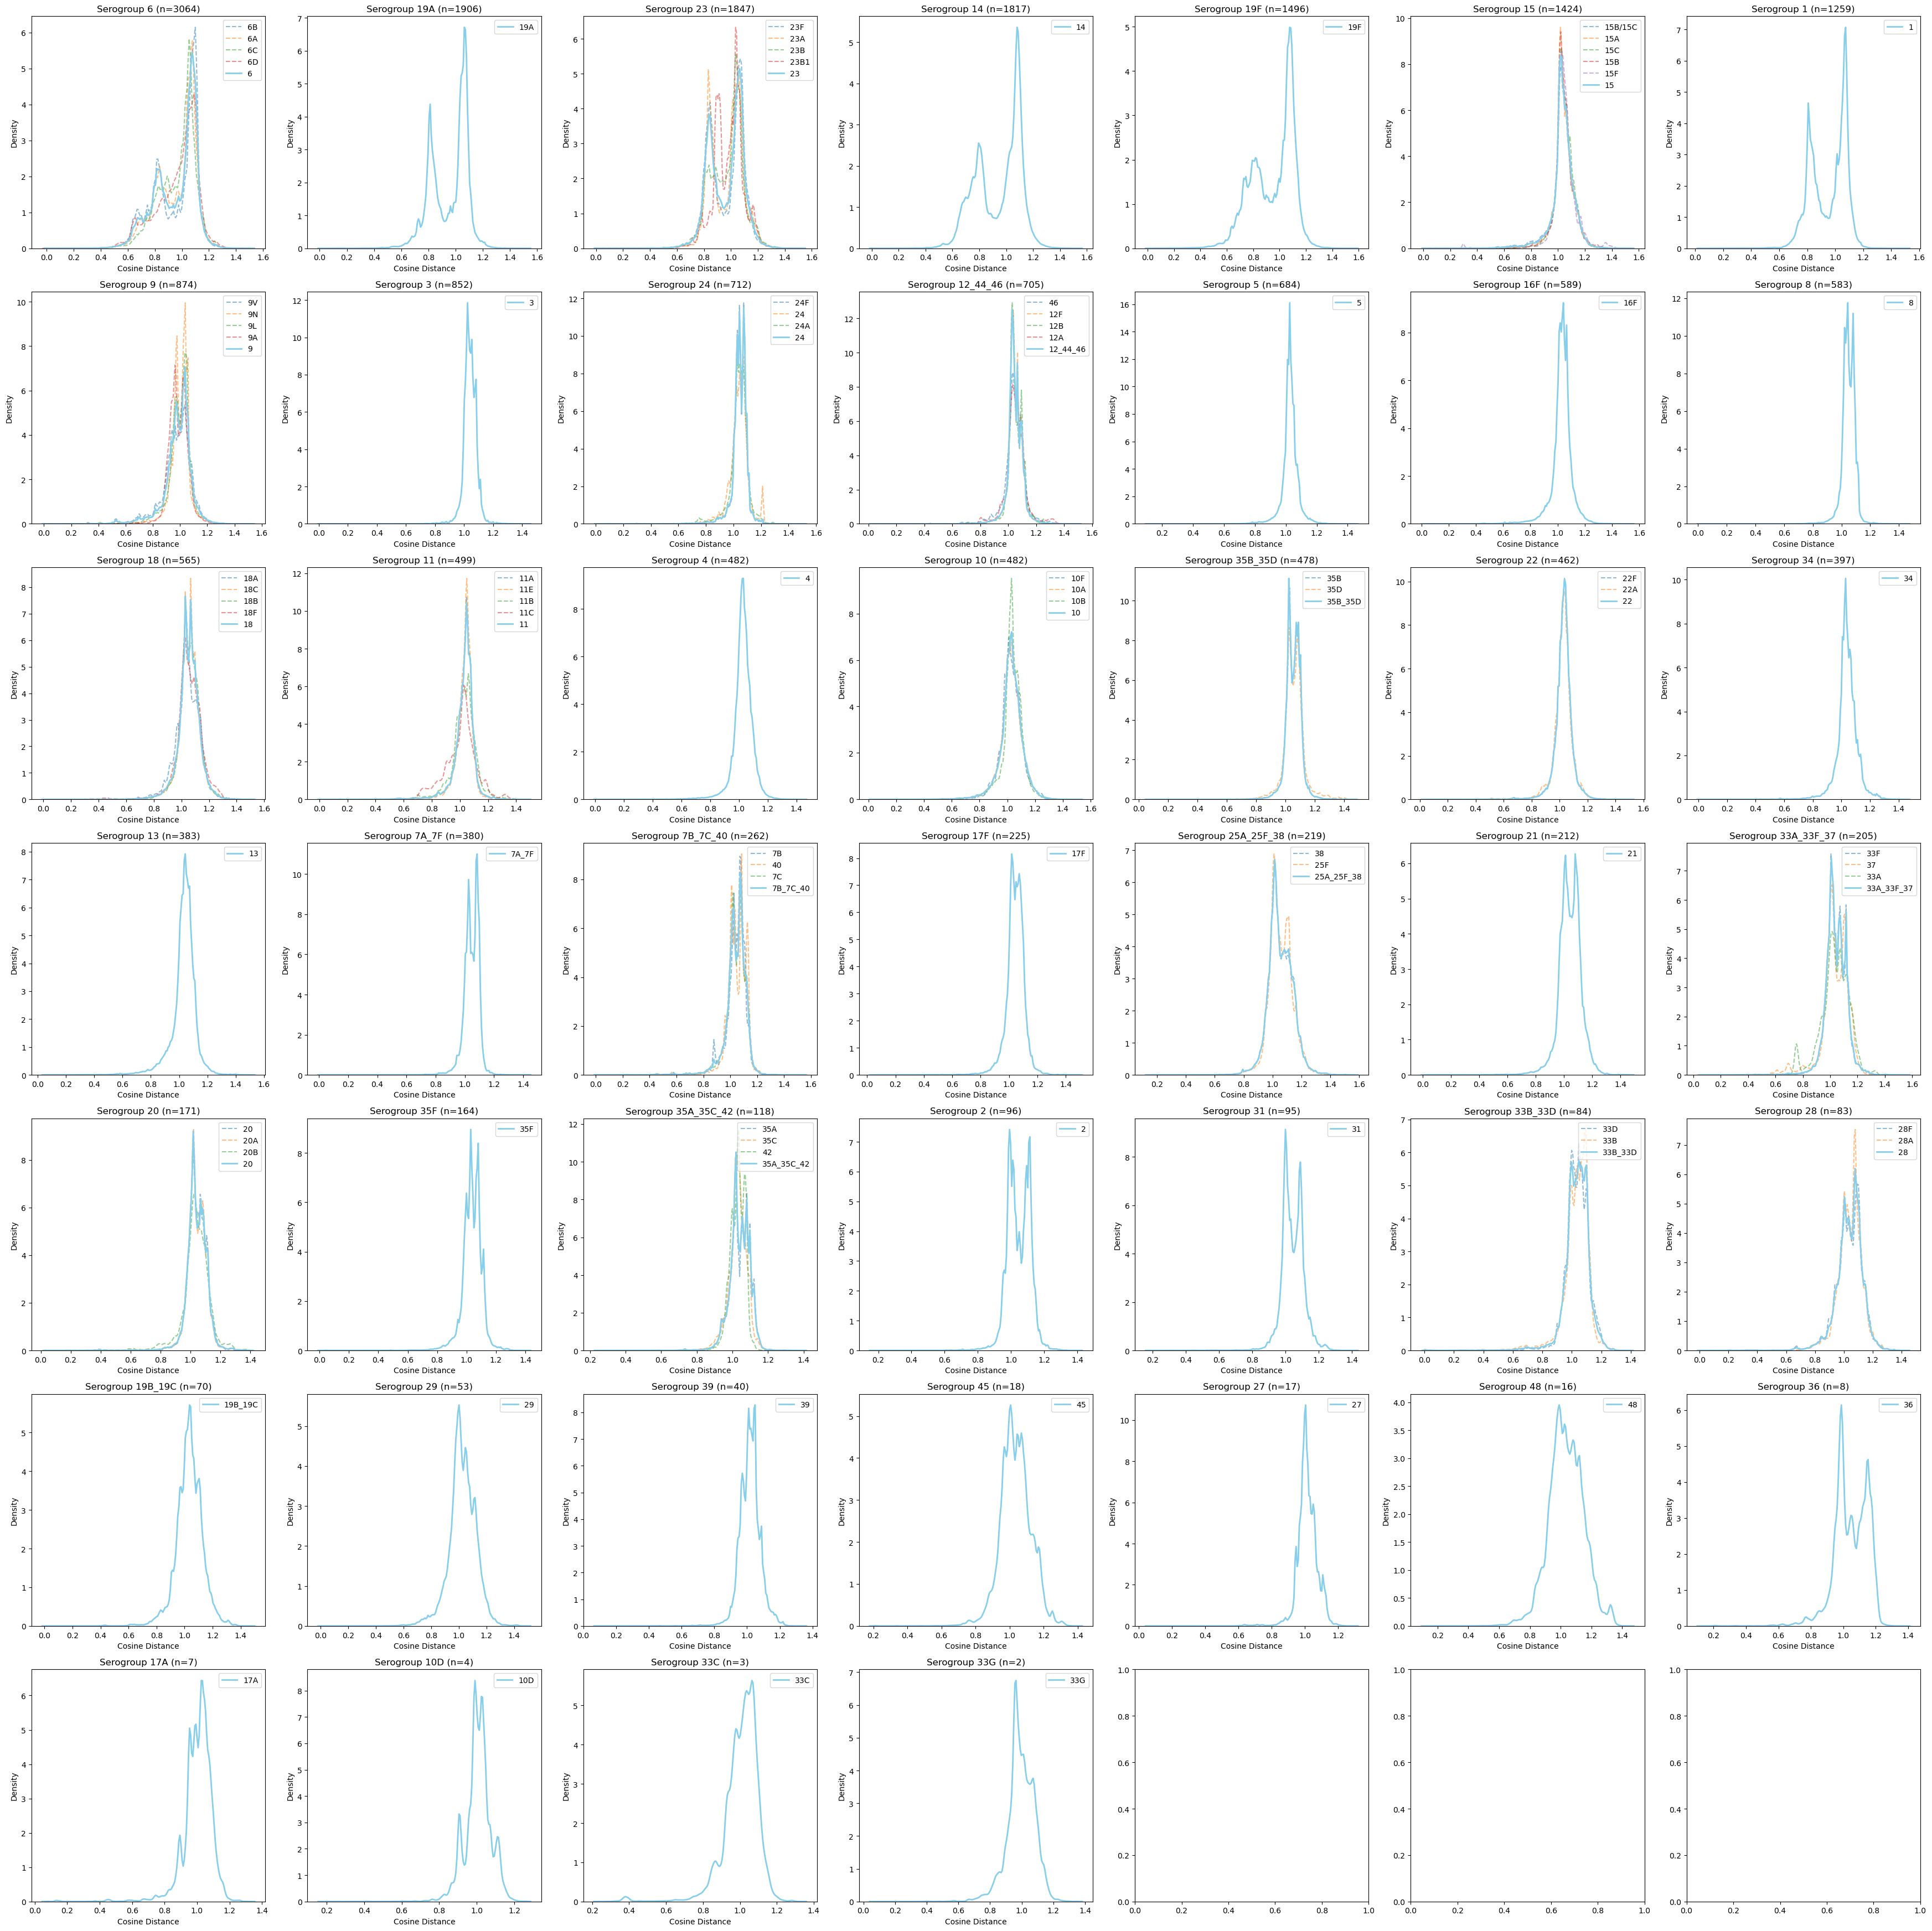

In [28]:
# now plot every serogroup against the rest
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(7, 7, figsize=(35, 35))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    # Filter X based on the current serotype
    # print(f"Processing serotype: {serotype} (n={count})")
    serotype_indices = group_labels[group_labels == serogroup].index
    rest_indices = group_labels[group_labels != serogroup].index
    submatrix = dist_matrix[serotype_indices][:, rest_indices]
    pairwise_distances_serotype = submatrix[np.triu_indices_from(submatrix, k=1)]

    # plot the fine labels on top of the coarse labels
    sub_serotypes = labels[serotype_indices].unique()
    if len(sub_serotypes) > 1:
        # Create a new axis for the sub-serotypes
        for sub_serotype in sub_serotypes:
            sub_serotype_indices = labels[labels == sub_serotype].index
            submatrix = dist_matrix[sub_serotype_indices][:, rest_indices]
            pairwise_distances_subserotype = submatrix[np.triu_indices_from(submatrix, k=1)]
            sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=axes[i], alpha=0.5, label=sub_serotype, linestyle='dashed')  # , color='orange'
            # axes[i].legend(title="Sub-serotype", loc='upper right')

    # Plot the density
    ax = axes[i]
    sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=2)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 2)

plt.tight_layout()
plt.show()

46it [00:28,  1.62it/s]


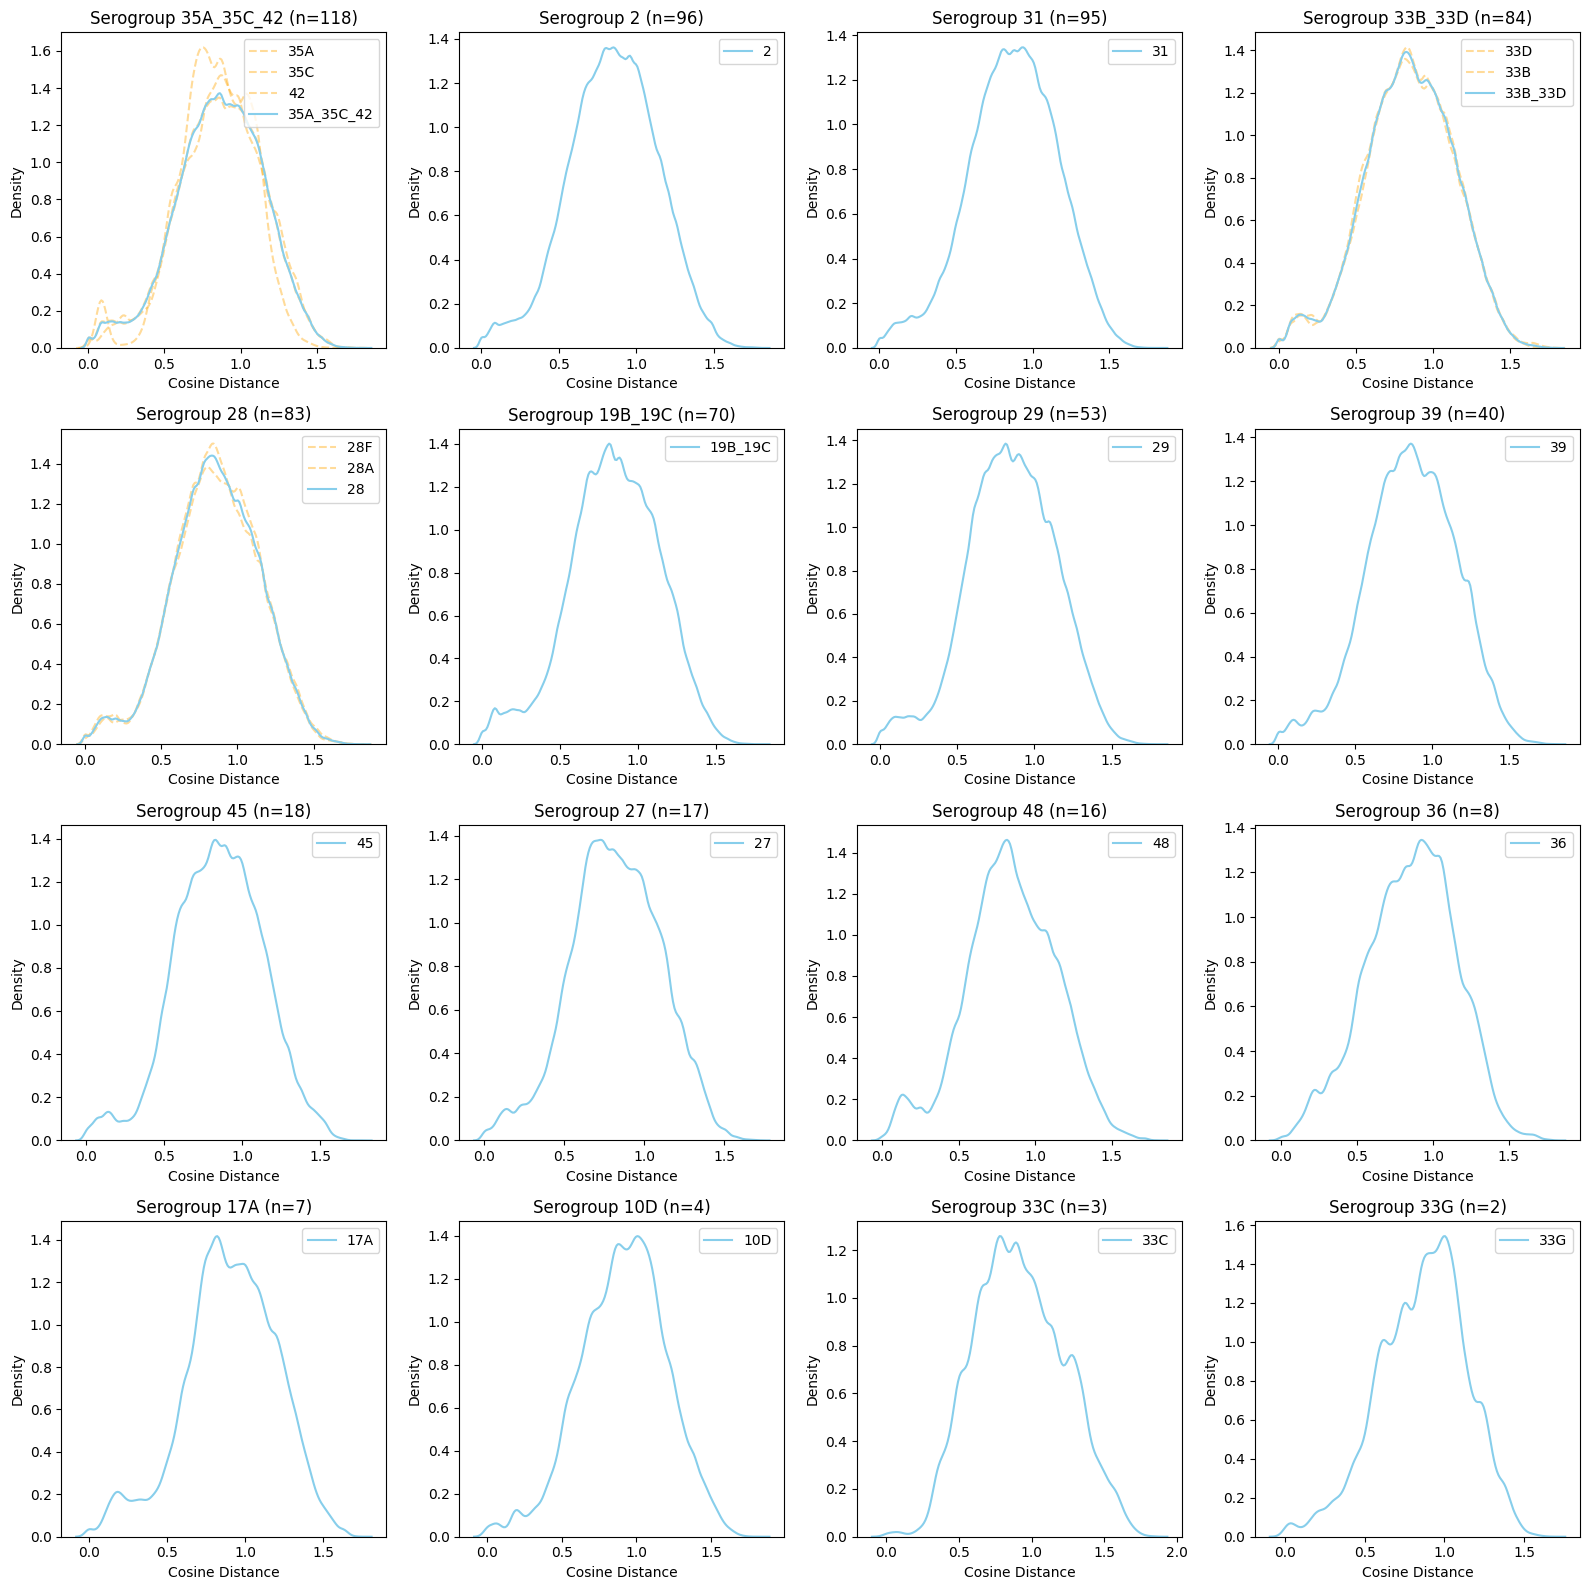

In [69]:
# now,again, the bottom 16 serogroups
SHOW_BOTTOM = 16
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    if i < 30:  # Skip the top serotypes
        continue
    ax = axes[i - 30]
    serotype_indices = group_labels[group_labels == serogroup].index
    rest_indices = group_labels[group_labels != serogroup].index
    submatrix = dist_matrix[serotype_indices][:, rest_indices]
    pairwise_distances_serotype = submatrix[np.triu_indices_from(submatrix, k=1)]

    # plot the fine labels on top of the coarse labels
    sub_serotypes = labels[serotype_indices].unique()
    if len(sub_serotypes) > 1:
        # Create a new axis for the sub-serotypes
        for sub_serotype in sub_serotypes:
            sub_serotype_indices = labels[labels == sub_serotype].index
            submatrix = dist_matrix[sub_serotype_indices][:, rest_indices]
            pairwise_distances_subserotype = submatrix[np.triu_indices_from(submatrix, k=1)]
            sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=ax, alpha=0.4, label=sub_serotype, color='orange', linestyle='dashed')
            # axes[i].legend(title="Sub-serotype", loc='upper right')

    # Plot the density
    sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=1.5)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')
# Adjust layout
plt.tight_layout()
plt.show()


### Non-cbl against each other

In [39]:
X_NONCBL = noncbl
X = np.concatenate([X, X_NONCBL], axis=0)
labels = pd.concat([labels, pd.DataFrame({"Serotype": [NONCBL_LABEL] * X_NONCBL.shape[0]})], axis=0)
len(labels), X.shape

(48479, (48479, 128))

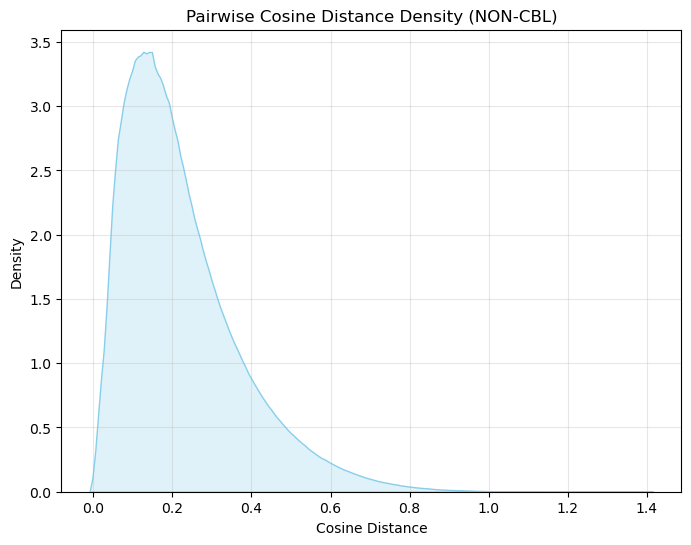

In [38]:
noncbl_dist = distance_function(X_NONCBL, X_NONCBL)
noncbl_dist = noncbl_dist[np.triu_indices_from(noncbl_dist, k=1)]
plt.figure(figsize=(8, 6))
sns.kdeplot(noncbl_dist, fill=True, color='skyblue')
plt.title('Pairwise Cosine Distance Density (NON-CBL)')
plt.xlabel('Cosine Distance')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.show()

### Serogroups vs. non-CBL

46it [08:28, 11.05s/it]


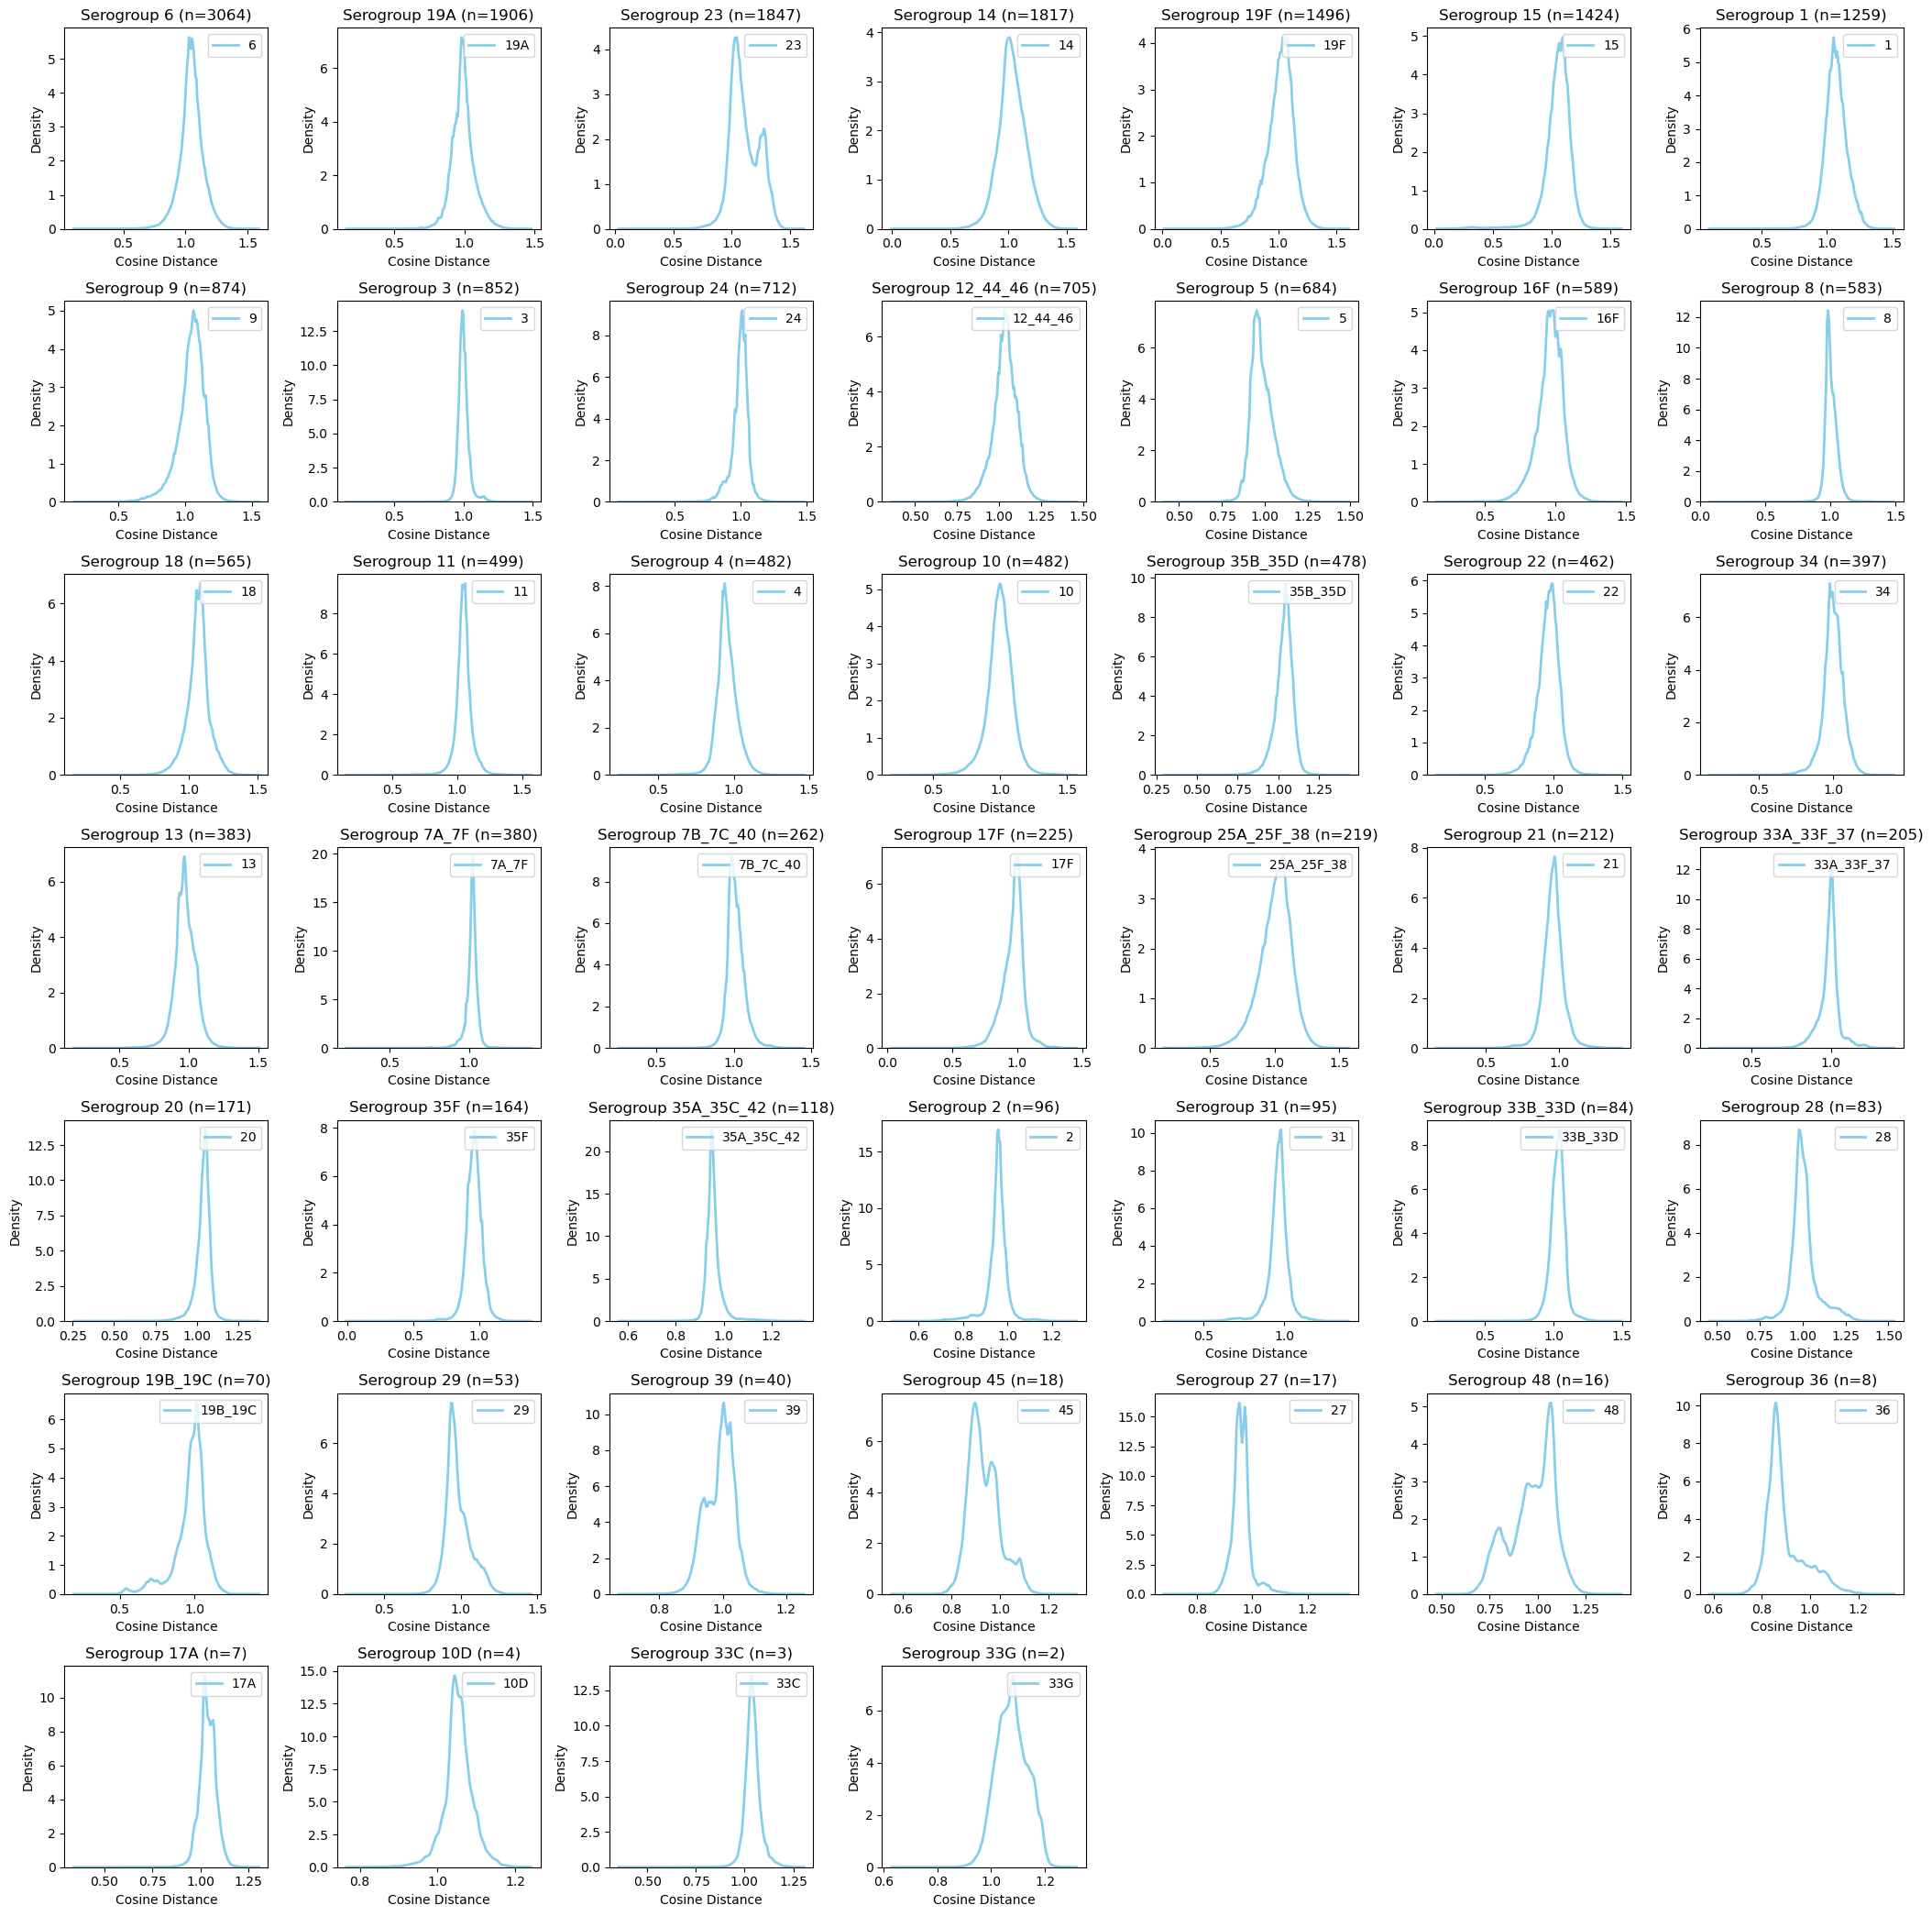

In [41]:
# now plot every serogroup against the rest
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(7, 7, figsize=(21, 21))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    if serogroup == NONCBL_LABEL:
        continue
    serotype_indices = group_labels[group_labels == serogroup].index
    sero_non_distances = cosine_distances(X[serotype_indices], X_NONCBL).flatten()

    # Plot the density
    ax = axes[i]
    sns.kdeplot(sero_non_distances, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=2)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 2)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

ValueError: The number of FixedLocator locations (46), usually from a call to set_ticks, does not match the number of labels (45).

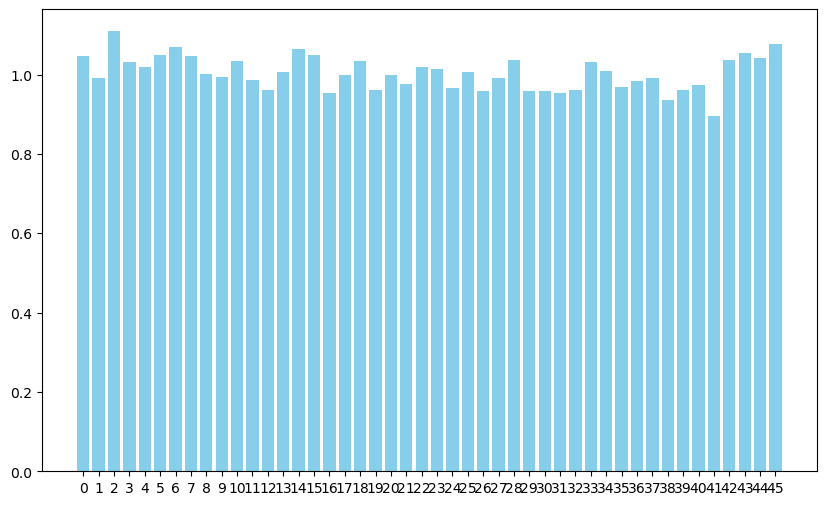

In [43]:
# Plot the mean distances
plt.figure(figsize=(10, 6))
plt.bar(range(len(mean_distances)), mean_distances, color='skyblue')
plt.xticks(range(len(mean_distances)), serotype_counts.index[1:], rotation=90)
plt.title('Mean Pairwise Cosine Distances to NON-CBL')
plt.xlabel('Serogroup')
plt.ylabel('Mean Cosine Distance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Baseline Jaccard distances

### Helper functions

In [2]:
import numpy as np
from scipy.sparse import csr_matrix, load_npz

def jaccard_distance_sparse(X_train: csr_matrix, X_query: csr_matrix) -> np.ndarray:
    """
    Compute the pairwise binary Jaccard distance between query and training samples

    Parameters
    ----------
    X_train : csr_matrix of shape (n_train, n_features)
        Sparse count matrix for training sequences.
    X_query : csr_matrix of shape (n_query, n_features)
        Sparse count matrix for query sequences.

    Returns
    -------
    distances : np.ndarray of shape (n_query, n_train)
        Binary Jaccard distances (1 - |A ∩ B| / |A U B|).
    """
    # Binarize: set all non-zero entries to 1
    B_train = X_train.copy()
    B_train.data[:] = 1
    B_query = X_query.copy()
    B_query.data[:] = 1

    # Intersection counts: (n_query, n_train)
    intersection = B_query.dot(B_train.T).toarray().astype(np.float64)


    # Union = |A| + |B| - |A ∩ B|
    sum_query = B_query.sum(axis=1).A1  # shape (n_query,)
    sum_train = B_train.sum(axis=1).A1  # shape (n_train,)
    union = sum_query[:, None] + sum_train[None, :] - intersection

    # Avoid division by zero (if both vectors are all-zero, define distance as 0)
    union[union == 0] = 1

    # Jaccard distance
    distances = 1.0 - (intersection / union)
    return distances


In [14]:
# load hashed kmer sketches stored as csr matrix in a npz file

sketches_path = "/Users/tajmirri/Documents/Workspace/data/gps/kmer_sketch.npz"
sketches = load_npz(sketches_path)
labels = pd.read_csv(LABELS_PATH, sep="\t")

is_duplicate = labels.duplicated()
if is_duplicate.any():
    print("Dropping duplicate label rows...")
    labels, sketches = labels[~is_duplicate], sketches[~is_duplicate]

known_indices = labels['Serotype'] != MISSING_LABEL
labels['Serotype'] = labels['Serotype'].fillna(MISSING_LABEL)

sketches, labels = sketches[known_indices], labels[known_indices]["Serotype"].reset_index(drop=True)
print(f"Loaded {len(labels)} sketches with {sketches.shape[1]} features.")
labels.head()

Dropping duplicate label rows...
Loaded 24119 sketches with 10000 features.


0    23F
1      5
2      3
3     20
4      3
Name: Serotype, dtype: object

Shape of sketches: (24119, 10000)
Plotting pairwise Jaccard distances for hashed kmer sketches...


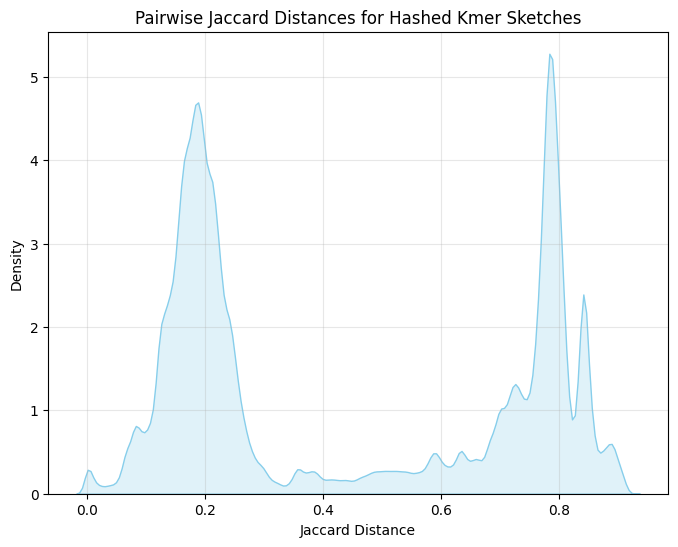

In [ ]:
TOP = sketches.shape[0]

print("Shape of sketches:", sketches[:TOP].shape)
distances = jaccard_distance_sparse(sketches[:TOP], sketches[:TOP])
distances = distances[np.triu_indices_from(distances, k=1)]
print("Plotting pairwise Jaccard distances for hashed kmer sketches...")

plot_everything(distances,
    title="Pairwise Jaccard Distances for Hashed Kmer Sketches",
    xlabel="Jaccard Distance"
)

In [ ]:
KMER_JACCARD_PATH = "/Users/tajmirri/Documents/Workspace/data/gps/pairwise_jaccard_distances.npz"
print(f"Saving pairwise distances to {KMER_JACCARD_PATH}")
np.savez(KMER_JACCARD_PATH, distances=distances, size=distances.shape[0])

Saving pairwise distances to /Users/tajmirri/Documents/Workspace/data/gps/pairwise_jaccard_distances.npz...
